# Cars4You - Handout Project | Group 42
## Notebook 1 — Models Lab
**Course:** MSc in Data Science and Advanced Analytics, NOVA IMS (2025/2026)  

**Author(s):** Group 42
- `Miguel Matos - 20221925`
- `Andre Nicolau - 20221918`
- `André Ferreira - 20250398`


---

#### <font> Table of Contents </font> <a class="anchor" id='toc'></a> 
1. [Imports](#Imports)  
2. [Modelling Testing](#modelling-testing) 
3. [Parameters Testing](#parameters-testing)
- 3.1.[Missing Values parameters](#missing-values-parameters)
- 3.2.[Outliers parameters](#outliers-parameters)
- 3.3.[Encoder parameters](#encoder-parameters)
- 3.4.[Features Selection Parameters](#feature-selection-parameters)
----

# Imports
[Back to TOC](#toc)

In [1]:
from utils.functions import *
from utils.Nuestra_Pipeline import NuestraPipeline
from Preprocessing_pipelines.Outliers_pipeline import OutliersDealer
from Preprocessing_pipelines.Missing_Values_pipeline import MissingValuesDealer
from Preprocessing_pipelines.Encoding_pipeline import EncodingDealer
from Preprocessing_pipelines.Scaling_pipeline import ScalingDealer
from Preprocessing_pipelines.Feature_Selection_pipeline import FeatureSelectionDealer
import warnings

# Suppress this specific warning
warnings.filterwarnings('ignore', 
                       message='X does not have valid feature names',
                       category=UserWarning,
                       module='sklearn.utils.validation')



data = pd.read_csv("../data/data_cleaned.csv", index_col= "carID")
pd.set_option("display.max_columns", None)

In [2]:
data = data.sample(frac=1).reset_index(drop=True)

In [3]:
data.head()

,Brand,model,car_age,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
0,VW,Golf,4.0,10912,Semi-Auto,64145.0,Petrol,30.0,53.3,1.4,36.0,3.0
1,VW,Golf,5.0,12219,Automatic,39482.0,Diesel,125.0,55.4,2.0,73.0,0.0
2,Mercedes,A class,1.0,28799,Semi-Auto,2000.0,Diesel,NaN,NaN,2.0,48.0,1.0
3,Mercedes,A class,4.0,16699,Manual,23052.0,Diesel,20.0,68.9,1.5,41.0,0.0
4,BMW,X1,0.0,37320,Semi-Auto,102.0,Petrol,145.0,39.8,2.0,98.0,2.0


As the objective is to create a predictive model that is accurate without the need of the mechanic's assessment, we'll drop the "paintQuality%" column.

In [4]:
data.drop("paintQuality%", axis = 1, inplace= True)

In [5]:
X = data.drop("price", axis= 1)
y = data["price"]

# Modelling Testing

Now, we'lll drop the missing values of "Brand", so that we can strtify the split on it.

In [22]:
data_testing = data.copy()

In [23]:
X_testing = data_testing.drop("price", axis= 1)
y_testing = data_testing["price"]

In [24]:
X_train, X_val, y_train, y_val = train_test_split(X_testing, y_testing, 
                                                    test_size= 0.3, 
                                                    random_state= 7, # 7 because of Ronaldo :)
                                                    shuffle= True
                                                    )

Data preprocessing on trainning data.

In [25]:
mvd = MissingValuesDealer(imputation_method= "knn_modelwise")
od = OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"])
ed = EncodingDealer(method="onehot")
sd = ScalingDealer(one_hot= True)
fsd = FeatureSelectionDealer(selection_method="kbest")

In [26]:
X_train = mvd.fit_transform(X_train)
output = od.fit_transform(X_train, y_train)

# Handle preprocessors that return only X or (X, y)
if isinstance(output, tuple):
    X_train, y_train = output
else:
    X_train = output
    y_train = y_train

X_train = ed.fit_transform(X_train, y_train) 
X_train = sd.fit_transform(X_train)
X_train = fsd.fit_transform(X_train, y_train)

Data preprocessing on validation data.

In [27]:
X_val = mvd.transform(X_val)
X_val = ed.transform(X_val)
X_val = sd.transform(X_val)
X_val = fsd.transform(X_val)

We'll start by conducting some initial tests to delete some options and making ou halving random search more effective.

In [28]:
lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, lr_pred)
print(f"MAE: {mae}")

MAE: 3169.127256471483


In [29]:
rf = RandomForestRegressor().fit(X_train, y_train)
rf_pred = rf.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, rf_pred)
print(f"MAE: {mae}")

MAE: 1665.7537817838763


In [15]:
etr = ExtraTreesRegressor().fit(X_train, y_train)
etr_pred = etr.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, etr_pred)
print(f"MAE: {mae}")

MAE: 1629.2705851956746


In [16]:
dt = DecisionTreeRegressor().fit(X_train, y_train)
dt_pred = dt.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, dt_pred)
print(f"MAE: {mae}")

MAE: 2028.319993235675


In [17]:
gb = GradientBoostingRegressor().fit(X_train, y_train)
gb_pred = gb.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, gb_pred)
print(f"MAE: {mae}")

MAE: 2267.3218920661025


In [18]:
hgb = HistGradientBoostingRegressor().fit(X_train, y_train)
hgb_pred = gb.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, hgb_pred)
print(f"MAE: {mae}")

MAE: 2267.3218920661025


In [ ]:
svr = SVR(kernel= "linear").fit(X_train, y_train)
svr_pred = svr.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, svr_pred)
print(f"MAE: {mae}")

Support Vector Machine takes significantly more time to run than the other algorithms.

In [34]:
knr = KNeighborsRegressor().fit(X_train, y_train)
knr_pred = knr.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, knr_pred)
print(f"MAE: {mae}")

MAE: 1858.3018866268867


### MLP's

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(25, 12, 1), max_iter= 100, early_stopping= True, n_iter_no_change= 5, verbose = True).fit(X_train, y_train)
mlp_pred = mlp.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, mlp_pred)
print(f"MAE: {mae}")

Iteration 1, loss = 8.44801179
Iteration 2, loss = 7.82265490
Iteration 3, loss = 7.78164498
Iteration 4, loss = 7.76522341
Iteration 5, loss = 7.75359265
Iteration 6, loss = 7.74378753
Iteration 7, loss = 7.73588180
Iteration 8, loss = 7.72873590
Iteration 9, loss = 7.72221580
Iteration 10, loss = 7.71677761
Iteration 11, loss = 7.71074448
Iteration 12, loss = 7.70455850
Iteration 13, loss = 7.69965160
Iteration 14, loss = 7.69435060
Iteration 15, loss = 7.68791923
Iteration 16, loss = 7.68244481
Iteration 17, loss = 7.67647363
Iteration 18, loss = 7.67020144
Iteration 19, loss = 7.66380114
Iteration 20, loss = 7.65753775
Iteration 21, loss = 7.65060301
Iteration 22, loss = 7.64360084
Iteration 23, loss = 7.63649635
Iteration 24, loss = 7.62931197
Iteration 25, loss = 7.62228844
Iteration 26, loss = 7.61458944
Iteration 27, loss = 7.60722782
Iteration 28, loss = 7.59931688
Iteration 29, loss = 7.59146459
Iteration 30, loss = 7.58355856
Iteration 31, loss = 7.57526010
Iteration 32, los

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MAE: 3749.9513687175427


<Axes: >

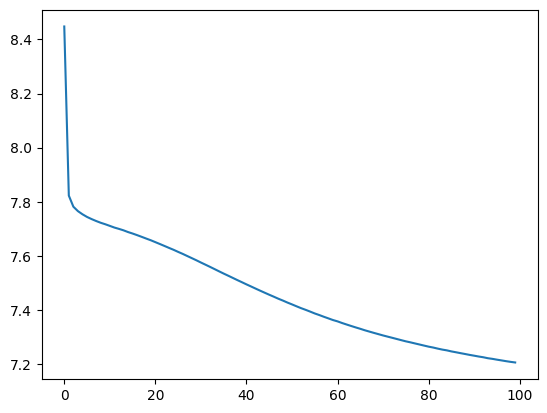

In [ ]:
losses = mlp.loss_curve_
iterations = range(mlp.n_iter_)
sns.lineplot(x = iterations, y = losses)

From the initial exploration that was done the algorithms that will be used in the random seearch will be:
- Decision Tree 
- Random Forests
- Extra Trees
- K Neighbours regressor
- Gradient Boosting 
- Hist Gradient Boosting 

MLP due to its extra complexity and big running time will be further analysed and runned on another random search.

# Parameters testing

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_testing, y_testing, 
                                                    test_size= 0.7, 
                                                    random_state= 7, # 7 because of Ronaldo :)
                                                    shuffle= True
                                                    )

## Missing Values parameters

We'll proceed to compare the four different method to compare the performance between them. As a base model for comparisons we'll use Random Forest Regressor.

In [11]:
rf = RandomForestRegressor()

model_modelwise = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

model_brandwise = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_brandwise"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

model_knn = NuestraPipeline(MissingValuesDealer(imputation_method= "knn"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)


model_simple = NuestraPipeline(MissingValuesDealer(imputation_method= "simple"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

model_iterative = NuestraPipeline(MissingValuesDealer(imputation_method= "iterative"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

In [48]:
model_modelwise.fit(X_train, y_train)
model_pred = model_modelwise.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"Modelwise MAE: {mae}")

Modelwise MAE: 1551.8374939047994


In [49]:
model_brandwise.fit(X_train, y_train)
model_pred = model_brandwise.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"Brandwise MAE: {mae}")

Brandwise MAE: 1561.5417308508793


In [50]:
model_knn.fit(X_train, y_train)
model_pred = model_knn.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"KNN MAE: {mae}")

KNN MAE: 1566.8557662562764


In [51]:
model_simple.fit(X_train, y_train)
model_pred = model_simple.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"Simple MAE: {mae}")

Simple MAE: 1575.4649380793082


In [52]:
model_iterative.fit(X_train, y_train)
model_pred = model_iterative.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"Iterative MAE: {mae}")

Iterative MAE: 1571.9359505957602


The performance is preaty similar between them all, but "knn" method is significantly slower, so we'll exclude that option.

## Outliers parameters

In [12]:
model_IQR = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "IQR", mod_outliers_cols= ["tax", "mpg"], sev_outliers_cols= ["car_age", "mileage", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

model_z = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "z_score", z_columns= ["car_age", "mileage", "tax", "mpg"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

model_log = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "log", log_columns= ["car_age", "mileage", "engineSize"], log_z_columns= ["tax", "mpg"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)


model_IF = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "Isolation_Forest", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

model_LOF = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

In [13]:
model_IQR.fit(X_train, y_train)
model_pred = model_IQR.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"model_IQR MAE: {mae}")

model_IQR MAE: 1511.7211040171185


In [14]:
model_z.fit(X_train, y_train)
model_pred = model_z.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"model_z MAE: {mae}")

model_z MAE: 1509.613377459724


In [15]:
model_log.fit(X_train, y_train)
model_pred = model_log.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"model_log MAE: {mae}")

model_log MAE: 7496.14207954929


In [87]:
model_IF.fit(X_train, y_train)
model_pred = model_IF.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"model_IF MAE: {mae}")

model_IF MAE: 1651.8812119056452


In [88]:
model_LOF.fit(X_train, y_train)
model_pred = model_LOF.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_pred)
print(f"model_LOF MAE: {mae}")

model_LOF MAE: 1552.4941298356946


The "Log" method got a really bad performance, so it will not be used in the searches.

## Encoder parameters

Let's start comparing the performance of Encoders, as there are only three options, we can easily see if there's a significant difference between them. 

In [62]:
model_ohe = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="onehot"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest"),
                           rf)

model_target = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

model_freq = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="freq"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

In [63]:
model_ohe.fit(X_train, y_train)
model_ohe_pred = model_ohe.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_ohe_pred)
print(f"One Hot Endoer MAE: {mae}")

One Hot Endoer MAE: 1787.0103729127552


In [64]:
model_target.fit(X_train, y_train)
model_target_pred = model_target.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_target_pred)
print(f"Target Encoder MAE: {mae}")

Target Encoder MAE: 1551.9449906322957


In [65]:
model_freq.fit(X_train, y_train)
model_freq_pred = model_freq.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_freq_pred)
print(f"Count Encoder MAE: {mae}")

Count Encoder MAE: 1669.2850580622928


Target and Count Encoders got significant better score than onehot encoder, which is a difference big enough to understand that the performance gap is big. For this reason we'll only use target and count encoder on the searches.

## Feature Selection Parameters

In this section, as most of the methods have one more parameters that change significantly its performance, we'll simply compare the runtime between the method and check if any of them is better to left out due to0 computation constraints.

In [79]:
model_kbest = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="onehot"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="kbest", k=10),
                           rf)

model_model = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="target"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="model", model_name= "rf",),
                           rf)

model_rfe = NuestraPipeline(MissingValuesDealer(imputation_method= "knn_modelwise"),
                           OutliersDealer(outlier_method= "LOF", model_columns= ["car_age", "mileage", "tax", "mpg", "engineSize"]), 
                           EncodingDealer(method="freq"), 
                           ScalingDealer(),
                           FeatureSelectionDealer(selection_method="rfe", model_name= "rf", n_features_to_select= 10),
                           rf)

In [80]:
model_kbest.fit(X_train, y_train)
model_kbest_pred = model_kbest.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_kbest_pred)
print(f"model_kbest MAE: {mae}")

model_kbest MAE: 1988.605503279095


In [81]:
model_model.fit(X_train, y_train)
model_model_pred = model_model.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_model_pred)
print(f"model_model MAE: {mae}")

model_model MAE: 1554.0833445396752


In [82]:
model_rfe.fit(X_train, y_train)
model_rfe_pred = model_rfe.predict(X_val)
r2, mae, rmse = calculate_regression_metrics(y_val, model_rfe_pred)
print(f"model_rfe MAE: {mae}")

model_rfe MAE: 1672.2378913326238


RFE and model methods helped to performe better than kbest did, but kbest is twice faster, so we'll keep them all.

### **Resume**:

- On Missing values, the "knn" method will be left out.
- On Outlier methods, "log" will not be used.
- On Encoding the "Onehot" encoding method will be left out as well.